In [2]:
# Problem 1, part a)
import numpy as np
import matplotlib.pyplot as plt
# import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier

# training = open("pendigits.tra").read()
# testing = open("pendigits.tes").read()

In [3]:
# train = pd.read_csv("pendigits.tra", header=None)
# test  = pd.read_csv("pendigits.tes", header=None)
# Seems like the end of each row is the number being used, so first I'll filter it to my UID (660516539)
train = np.loadtxt("pendigits.tra", delimiter=",")
test  = np.loadtxt("pendigits.tes", delimiter=",")

#data seems unlabeled. iloc works
# nvm using numpy instead because iloc is ugly
coords_train = train[:,:-1] 
labels_train = train[:,-1]

coords_test = test[:,:-1] 
labels_test = test[:,-1]

train_filter = (labels_train == 3) | (labels_train == 9)
coords_train = coords_train[train_filter]
labels_train = labels_train[train_filter]

test_filter = (labels_test == 3) | (labels_test == 9)
coords_test = coords_test[test_filter]
labels_test = labels_test[test_filter]
# 
#filtered to 3 and 9 

In [4]:
#The "naive" linear regression is interpreting 3 as 0 and 9 as 1, I think.
y_train_binary = (labels_train == 9).astype(int) #labels_train ==9 is True or False, gets turned into an int
y_test_binary = (labels_test == 9).astype(int)

#training data is for the model -- compare it versus the test to see how it compares

linreg = LinearRegression()
linreg.fit(coords_train, y_train_binary)
y_predicted_cont = linreg.predict(coords_test) #continuous prediction based on the coords test (NOT the label)
y_predicted_lin = (y_predicted_cont >= 0.5).astype(int) #conversion to a binary classifer

errors = (y_predicted_lin != y_test_binary).sum()
totalpoints = len(y_test_binary)
'''
for i in range(len(y_predicted_lin)):
    if (y_predicted_lin[i] != y_test_binary[i]): 
        errors +=1
    totalpoints += 1 
this doesn't work because the indices are kind of 1d arrays due to numpy    
'''
lin_error = errors / totalpoints


#basically, make a model that predicts if it's 3 or 9 (0 or 1) and if it's above 0.5, then it's 1. If it's wrong, that's a point to errors.w    
# it looks at the 20 coordinate points (doesn't see them as coordinates. idk how to) and predicts based on that.
# fit is making the regression and storing it, predict is telling you to take the model and make a prediction based on the points
# https://towardsdatascience.com/fit-vs-predict-vs-fit-predict-in-python-scikit-learn-f15a34a8d39f/ 
knn_errors = []
for k in range(1, 21): 
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(coords_train, y_train_binary)
    y_pred_knn = knn.predict(coords_test)
    errors = (y_pred_knn != y_test_binary).sum()
    totalpoints = len(y_test_binary)
    knn_errors.append(errors/totalpoints)

# For each point, grabs the 20 nearest point's in the dataset and sees if it's majority 3 or 9 and then decides. 
print(len(y_train_binary)) # n for the degrees of freedom
print(knn_errors[0])


1438
0.011904761904761904


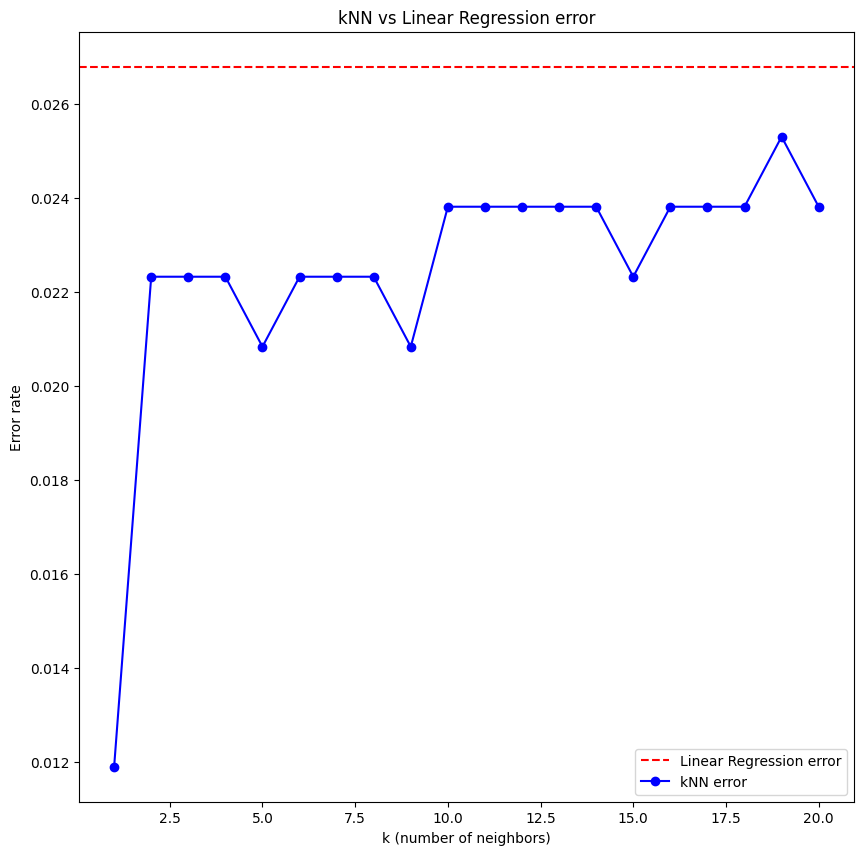

In [5]:
plt.figure(figsize=(10,10))
k_values = range(1, 21)
plt.axhline(y=lin_error, color='r', linestyle='--', label="Linear Regression error")
plt.plot(k_values, knn_errors, color='b', marker='o', label="kNN error")
plt.xlabel("k (number of neighbors)")
plt.ylabel("Error rate")
plt.title("kNN vs Linear Regression error")
plt.legend()
plt.show()

# Problem 1, part b)

The plot is very much not U-shaped, but I think it's due to the fact that 3 and 9 are both similar, right-side arching numbers. The best k is actually 1...

The degrees of freedom for a kNN is k/n, which would be 1438, with an error of 0.011904761904761904. 


In [6]:
# Problam 2 part (a) [5 points] Generate 4 independent standard Normal variables X1, X2, X3, X4 of n = 1000
# independent observations. You can then generate a response Y as follows:
# Y = X1 + 2 · X2 − X3 + ε
# with IID N (0, 1) errors ε. Set the random seed to 598 for reproducibility.

np.random.seed(598)
n = 1000
X1 = np.random.normal(0, 1, n)
X2 = np.random.normal(0, 1, n)
X3 = np.random.normal(0, 1, n)
X4 = np.random.normal(0, 1, n)
epsilon = np.random.normal(0, 1, n)
Y = X1 + (2*X2)-X3 + epsilon

In [7]:
#    Problem 2 part (b)
#    Use the appropriate kN N function in R or Python and report the mean squared
#    error (MSE) for your prediction with k = 4. Use the first 500 observations as the training
#    data and the rest as testing data. Predict the response using the built-in kN N function
#    with k = 5.

from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

X = np.column_stack((X1, X2, X3, X4)) # I think epsilon is noise? and not accounted for in this X to differentiate Y from the factors
x_train, x_test = X[:500], X[500:]  
y_train, y_test = Y[:500], Y[500:]

# okay -- basically there's factors (x1, x2, x3, and x4) and a result (y).
# There's also a hidden factor epsilon that we pretend not to know of.
# we find an association between x1, x2, x3, and x4, and y

knn1 = KNeighborsRegressor(n_neighbors=4)
knn1.fit(x_train, y_train)
y_predict4 = knn1.predict(x_test)

knn2 = KNeighborsRegressor(n_neighbors=5)
knn2.fit(x_train, y_train)
y_predict5 = knn2.predict(x_test)


mse4 = mean_squared_error(y_test, y_predict4)
mse5 = mean_squared_error(y_test, y_predict5)
print("MSE with k=4:", mse4)
print("MSE with k=5:", mse5)    

MSE with k=4: 1.5400756698787827
MSE with k=5: 1.3978324747917983


In [8]:
# Problem 3 part (c)
#  For this question, you cannot load any additional packages. Write your own
# kN N function, mykNN (xtrain, ytrain, xtest, k), that fits a kNN model and predicts
# multiple target points xtest. The function should return a variable ytest.

#ok, basically how I'm going to tackle this is:
# for loop in the "x_test", and for each datapoint, we find the most similar k points on x_train
#  then we... average those out and get our result 

def distance(point1, point2):
    if len(point2) != len(point1):
        raise ValueError("Dimension Mismatch")
    total = 0
    for i in range(len(point1)):
        vec = (point1[i] - point2[i])
        total += (vec * vec)
    # not really neccesary to sqrt 
    return total

def mykNN(xtrain, ytrain, xtest, k) :
    ytest = []
    for testpoint in xtest:
        distances = []
        for i in range(len(xtrain)):
            dist = distance(testpoint,xtrain[i])
            #numpy function to get distance from any two points
            distances.append((dist,ytrain[i])) #storing tuple
        distances.sort(key = lambda x: x[0])
        kneighbors = distances[:k]
        neighborsum = 0
        '''
        for i in kneighbors:
            neighborsum += i[1]
            '''
        for dist,val in kneighbors:
            neighborsum += val
        ytest.append(neighborsum/k)
    return ytest

In [ ]:
#testing kNN

ypredict4 = mykNN(x_train, y_train, x_test, 4)
ypredict5 = mykNN(x_train, y_train, x_test, 5)

mse4 = mean_squared_error(y_test, ypredict4)
mse5 = mean_squared_error(y_test, ypredict5)
print (mse4, mse5)

# MSE code: 1 / n ( sum of each point's difference squared)
leng = len(y_test)

ydif4 = ypredict4 - y_test
ydif4 = ydif4 ** 2

ydif5 = ypredict5 - y_test
ydif5 = ydif5 ** 2 
print("MSE with k4:", sum(ydif4)/leng)
print("MSE with k5:", sum(ydif5)/leng)




1.5400756698787827 1.3978324747917983
MSE with k4: 1.540075669878783
MSE with k4: 1.3978324747917972
